# EDA OF TITANIC DATASET

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [55]:
df = pd.read_csv('data/raw.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    object 
 4   Sex          714 non-null    object 
 5   Age          714 non-null    int64  
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    object 
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    object 
 11  Embarked     712 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 67.1+ KB


In [57]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         2
dtype: int64

In [58]:
df.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35,0,0,8.0500,S


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  714 non-null    int64  
 1   Pclass    714 non-null    int64  
 2   Name      714 non-null    object 
 3   Sex       714 non-null    object 
 4   Age       714 non-null    int64  
 5   SibSp     714 non-null    int64  
 6   Parch     714 non-null    int64  
 7   Fare      714 non-null    float64
 8   Embarked  712 non-null    object 
dtypes: float64(1), int64(5), object(3)
memory usage: 50.3+ KB


In [60]:
df['Sex'] = df['Sex'].map({"male":1, "female":0})
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",1,22,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",0,26,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",1,35,0,0,8.0500,S


In [61]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [62]:
df['Embarked'].value_counts()

Embarked
S    554
C    130
Q     28
Name: count, dtype: int64

In [63]:
df[df['Embarked'].isnull()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
46,1,1,"Icard, Miss. Amelie",0,38,0,0,80.0,NaN
662,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",0,62,0,0,80.0,NaN


In [64]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [65]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [66]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)

In [67]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",1,22,1,0,7.2500,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,1,0,71.2833,0,0
2,1,3,"Heikkinen, Miss. Laina",0,26,0,0,7.9250,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,53.1000,0,1
4,0,3,"Allen, Mr. William Henry",1,35,0,0,8.0500,0,1


In [68]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [69]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title
0,0,3,"Braund, Mr. Owen Harris",1,22,1,0,7.2500,0,1,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,1,0,71.2833,0,0,Mrs
2,1,3,"Heikkinen, Miss. Laina",0,26,0,0,7.9250,0,1,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,53.1000,0,1,Mrs
4,0,3,"Allen, Mr. William Henry",1,35,0,0,8.0500,0,1,Mr


In [70]:
df.drop('Name', axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title
0,0,3,1,22,1,0,7.2500,0,1,Mr
1,1,1,0,38,1,0,71.2833,0,0,Mrs
2,1,3,0,26,0,0,7.9250,0,1,Miss
3,1,1,0,35,1,0,53.1000,0,1,Mrs
4,0,3,1,35,0,0,8.0500,0,1,Mr


In [71]:
df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [72]:
df['Title'] = df['Title'].replace([
    'Lady', 'Countess','Capt', 'Col',
    'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer'
], 'Rare')

df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

In [73]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title
0,0,3,1,22,1,0,7.2500,0,1,Mr
1,1,1,0,38,1,0,71.2833,0,0,Mrs
2,1,3,0,26,0,0,7.9250,0,1,Miss
3,1,1,0,35,1,0,53.1000,0,1,Mrs
4,0,3,1,35,0,0,8.0500,0,1,Mr


In [74]:
df.groupby('Title')['Survived'].mean().sort_values(ascending=False)

Title
Mrs       0.788991
Miss      0.724832
Master    0.583333
Rare      0.363636
Mr        0.168342
Name: Survived, dtype: float64

In [75]:
df = pd.get_dummies(df, columns=['Title'], drop_first=True, dtype=int)

In [76]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,1,22,1,0,7.2500,0,1,0,1,0,0
1,1,1,0,38,1,0,71.2833,0,0,0,0,1,0
2,1,3,0,26,0,0,7.9250,0,1,1,0,0,0
3,1,1,0,35,1,0,53.1000,0,1,0,0,1,0
4,0,3,1,35,0,0,8.0500,0,1,0,1,0,0


In [77]:
df.groupby('Pclass')['Survived'].size()

Pclass
1    186
2    173
3    355
Name: Survived, dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

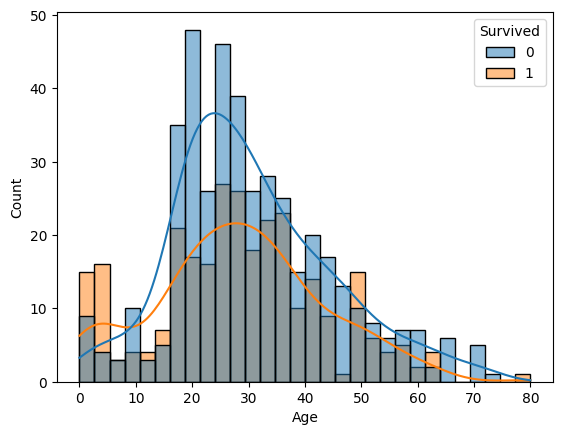

In [78]:
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)

<Axes: xlabel='Age', ylabel='Count'>

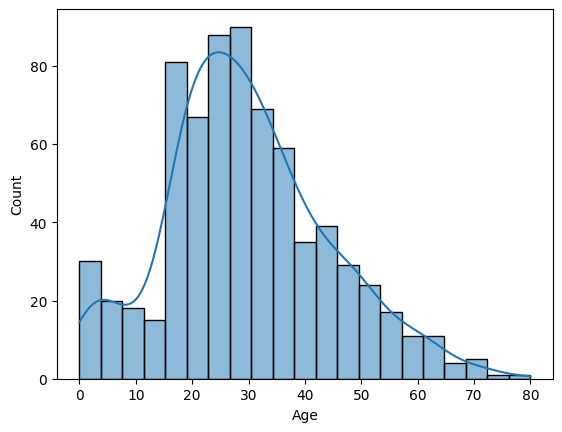

In [79]:
sns.histplot(x='Age', data=df, kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

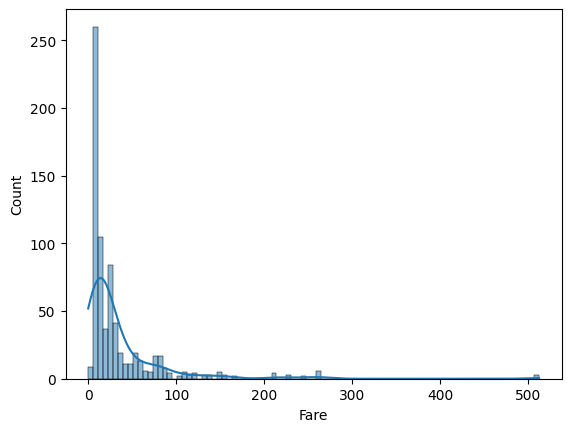

In [80]:
sns.histplot(x='Fare', data=df, kde=True)

In [81]:
df['Fare'] = np.log(df['Fare'] + 1)

<Axes: xlabel='Fare', ylabel='Count'>

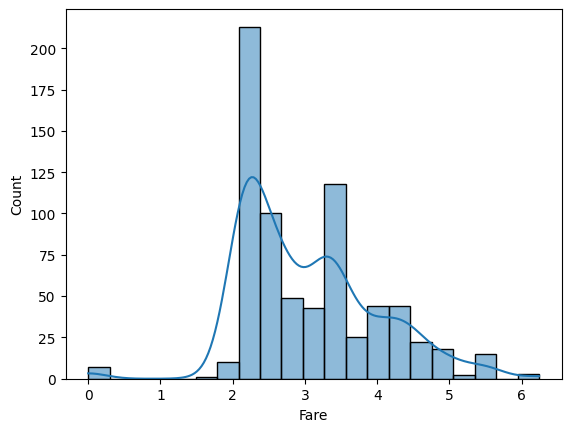

In [82]:
sns.histplot(x='Fare', data=df, kde=True)

In [83]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000
mean,0.406162,2.236695,0.634454,29.712885,0.512605,0.431373,3.042013,0.039216,0.778711,0.208683,0.557423,0.152661,0.030812
std,0.491460,0.838250,0.481921,14.529273,0.929783,0.853289,0.952459,0.194244,0.415405,0.406653,0.497040,0.359913,0.172930
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,20.250000,0.000000,0.000000,2.202765,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,2.000000,1.000000,28.000000,0.000000,0.000000,2.817903,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,38.000000,1.000000,1.000000,3.537310,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,3.000000,1.000000,80.000000,5.000000,6.000000,6.240917,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='Fare'>

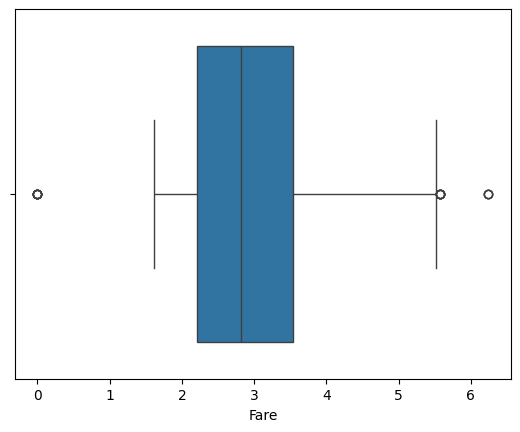

In [84]:
sns.boxplot(x='Fare', data=df)

In [87]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [88]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilySize
0,0,3,1,22,1,0,2.110213,0,1,0,1,0,0,2
1,1,1,0,38,1,0,4.280593,0,0,0,0,1,0,2
2,1,3,0,26,0,0,2.188856,0,1,1,0,0,0,1
3,1,1,0,35,1,0,3.990834,0,1,0,0,1,0,2
4,0,3,1,35,0,0,2.202765,0,1,0,1,0,0,1
